## Résolution par PINN (PyTorch)

Dans cette partie, nous utilisons un **Physics-Informed Neural Network (PINN)** implémenté avec **PyTorch** afin d'obtenir une approximation numérique de la solution du problème de conduction thermique.

Contrairement à la méthode des éléments finis, le PINN ne repose pas sur un maillage. Le réseau de neurones est entraîné en minimisant une fonction de perte construite à partir de l'équation aux dérivées partielles ainsi que des conditions aux limites de Dirichlet.

Le problème considéré est

$$
\begin{cases}
-\nabla \cdot \left(k(x,y)\nabla u\right)=1000, & \text{dans } \Omega,\\[4pt]
u=0, & \text{sur } \partial\Omega,
\end{cases}
$$

avec

$$
\Omega=(0,1)\times(0,1)\subset\mathbb{R}^{2},
$$

et

$$
k(x,y)=
\begin{cases}
205,& x<0.5,\\
50,& x\ge0.5.
\end{cases}
$$

Le réseau est entraîné à approximer directement la température \(u(x,y)\) en satisfaisant les lois physiques imposées par l'équation différentielle.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [12]:
df_matlab = pd.read_csv('/kaggle/input/datasets/karimchibani/data-matlab/solution_matlab_direct.csv')
df_matlab.head()

,X,Y,U_matlab
0,0.0,0.000,0.000000e+00
1,0.0,0.025,-7.793563e-18
2,0.0,0.050,1.861887e-15
3,0.0,0.075,-6.775433e-16
4,0.0,0.100,-3.186686e-14


In [9]:
df_matlab.shape

(1681, 3)

In [27]:
#_______________________________Résolution par PINN (PyTorch)¶______________________________________________________#
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# =========================================================================
# 1. ARCHITECTURE DU PINN (Réseau Unique pour Conductivité Variable)
# =========================================================================
class ConfigurationPINN(nn.Module):
    def __init__(self):
        super(ConfigurationPINN, self).__init__()
        # 4 couches cachées pour donner la flexibilité nécessaire au réseau
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x, y):
        X = torch.cat([x, y], dim=1)
        u_nn = self.net(X)
        # Imposition exacte des conditions de Dirichlet homogènes u=0 sur les bords
        return x * (1.0 - x) * y * (1.0 - y) * u_nn

# =========================================================================
# 2. GENERATION DES POINTS DE COLLOCATION (Échantillonnage ciblé à X=0.5)
# =========================================================================
N_domaine = 5000

# Points uniformes
x_uni = torch.rand(N_domaine, 1)
y_uni = torch.rand(N_domaine, 1)

# Points denses autour du saut de conductivité à X = 0.5
x_dense = 0.5 + 0.08 * torch.randn(1500, 1)
x_dense = torch.clamp(x_dense, 0.0, 1.0)
y_dense = torch.rand(1500, 1)

x_dom = torch.cat([x_uni, x_dense], dim=0)
y_dom = torch.cat([y_uni, y_dense], dim=0)
x_dom.requires_grad = True
y_dom.requires_grad = True

# =========================================================================
# 3. INITIALISATION DU MODELE ET DES OPTIMISEURS
# =========================================================================
model = ConfigurationPINN()
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)

optimizer_lbfgs = optim.LBFGS(
    model.parameters(), 
    lr=0.5, 
    max_iter=1500, 
    tolerance_grad=1e-7, 
    tolerance_change=1e-9, 
    line_search_fn="strong_wolfe"
)

# =========================================================================
# 4. FONCTION DE PERTE PDE (Calcul du flux pour k variable)
# =========================================================================
def calculer_loss_pde():
    u_dom = model(x_dom, y_dom)
    
    # Gradients premiers (du/dx et du/dy)
    du_dx = torch.autograd.grad(u_dom, x_dom, torch.ones_like(u_dom), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_dom, y_dom, torch.ones_like(u_dom), create_graph=True)[0]
    
    # Définition de la conductivité variable comme dans MATLAB
    k = torch.where(x_dom < 0.5, torch.tensor(205.0), torch.tensor(50.0))
    
    # Calcul des composantes du Flux
    flux_x = k * du_dx
    flux_y = k * du_dy
    
    # Divergence du flux (Dérivées secondes appliquées au flux)
    dflux_x_dx = torch.autograd.grad(flux_x, x_dom, torch.ones_like(flux_x), create_graph=True)[0]
    dflux_y_dy = torch.autograd.grad(flux_y, y_dom, torch.ones_like(flux_y), create_graph=True)[0]
    
    # Résidu de la forme forte : -div(k*grad(u)) - f = 0
    f_source = 1000.0
    pde_residual = - (dflux_x_dx + dflux_y_dy) - f_source
    
    return torch.mean(pde_residual ** 2)

# =========================================================================
# 5. ENTRAÎNEMENT HYBRIDE (ADAM PUIS L-BFGS)
# =========================================================================
print("--- Phase 1 : Entraînement global avec Adam ---")
for epoch in range(6000):
    optimizer_adam.zero_grad()
    loss = calculer_loss_pde()
    loss.backward()
    optimizer_adam.step()
    if epoch % 1000 == 0:
        print(f"Adam Époque {epoch:4d} | Perte PDE: {loss.item():.4e}")

print("\n--- Phase 2 : Finition de haute précision avec L-BFGS ---")
def closure():
    optimizer_lbfgs.zero_grad()
    loss = calculer_loss_pde()
    loss.backward()
    return loss

optimizer_lbfgs.step(closure)
print("Entraînement terminé avec succès !")
# =========================================================================
# 6. EVALUATION ET CORRECTION DU MAILLAGE DE TEST
# =========================================================================
x_espace = np.linspace(0, 1, 100)
y_espace = np.linspace(0, 1, 100)
X_mesh, Y_mesh = np.meshgrid(x_espace, y_espace)

x_tensor = torch.tensor(X_mesh.flatten(), dtype=torch.float32).view(-1, 1)
y_tensor = torch.tensor(Y_mesh.flatten(), dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    u_prediction = model(x_tensor, y_tensor).numpy()
U_PINN = u_prediction.reshape(X_mesh.shape)



--- Phase 1 : Entraînement global avec Adam ---
Adam Époque    0 | Perte PDE: 9.9087e+05
Adam Époque 1000 | Perte PDE: 1.1573e+05
Adam Époque 2000 | Perte PDE: 1.1304e+04
Adam Époque 3000 | Perte PDE: 6.0795e+03
Adam Époque 4000 | Perte PDE: 4.4672e+03
Adam Époque 5000 | Perte PDE: 3.9347e+03

--- Phase 2 : Finition de haute précision avec L-BFGS ---
Entraînement terminé avec succès !


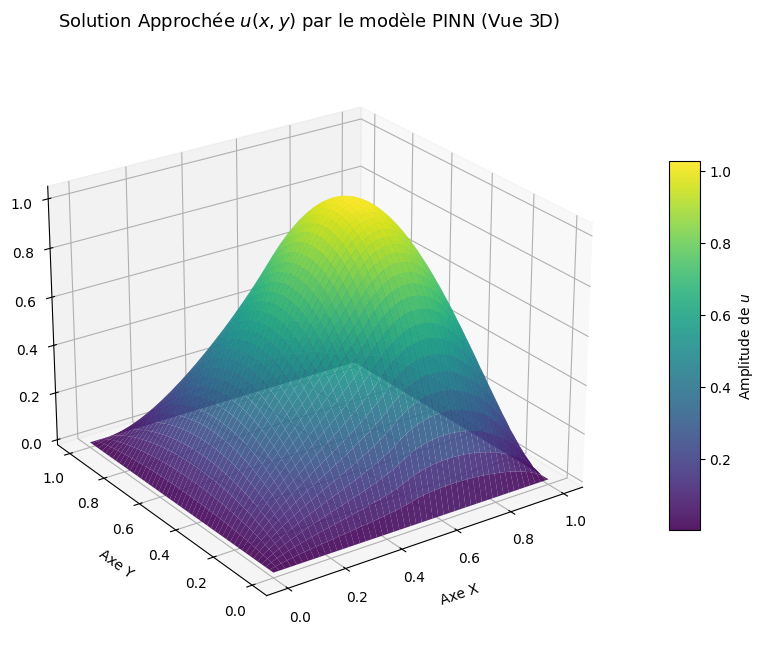

--> La valeur maximale (Max u) du PINN est : 1.02877


In [30]:
import matplotlib.pyplot as plt
from matplotlib import cm

# Initialisation de la figure 3D
fig_3d = plt.figure(figsize=(10, 8), facecolor='w')
ax_3d = fig_3d.add_subplot(111, projection='3d')

# Tracé de la surface 3D de la solution PINN
surf = ax_3d.plot_surface(X_mesh, Y_mesh, U_PINN, cmap=cm.viridis,
                          linewidth=0, antialiased=True, alpha=0.9)

# Configuration des étiquettes et du titre
ax_3d.set_title('Solution Approchée $u(x,y)$ par le modèle PINN (Vue 3D)', fontsize=13, pad=15)
ax_3d.set_xlabel('Axe X', fontsize=10, labelpad=8)
ax_3d.set_ylabel('Axe Y', fontsize=10, labelpad=8)
ax_3d.set_zlabel('$u(x,y)$', fontsize=10, labelpad=8)

# Ajout d'une barre de couleur (Colorbar)
cbar_3d = fig_3d.colorbar(surf, ax=ax_3d, shrink=0.6, aspect=12, pad=0.08)
cbar_3d.set_label('Amplitude de $u$', fontsize=10)

# Ajustement de l'angle de vue pour bien observer l'asymétrie induite à X=0.5
# (25 degrés d'élévation, -125 degrés d'azimut)
ax_3d.view_init(elev=25, azim=-125)

# Affichage du graphique
plt.show()
print(f"--> La valeur maximale (Max u) du PINN est : {U_PINN.max():.5f}")

MAE  = 0.093796
RMSE = 0.125434


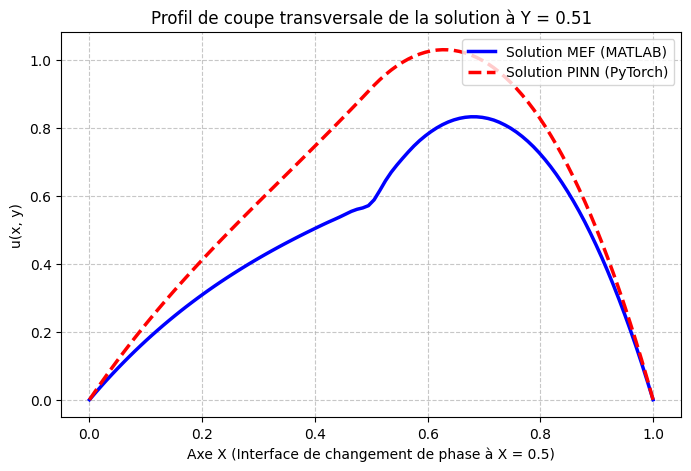

In [35]:
#______________Etude comparative entre la méthode des éléments finis (FEM) et les réseaux de neurones informés par la physique (PINNs).____
import numpy as np
import pandas as pd
import torch
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# =========================================================================
# 1. EVALUATION DU PINN SUR UNE GRILLE REGULIERE 100x100
# =========================================================================
# Création d'une grille uniforme [0,1]x[0,1] pour l'affichage et la comparaison
x_espace = np.linspace(0, 1, 100)
y_espace = np.linspace(0, 1, 100)
X_mesh, Y_mesh = np.meshgrid(x_espace, y_espace)

# Conversion de la grille en tenseurs PyTorch pour le modèle
x_tensor = torch.tensor(X_mesh.flatten(), dtype=torch.float32).view(-1, 1)
y_tensor = torch.tensor(Y_mesh.flatten(), dtype=torch.float32).view(-1, 1)

# Prédiction par le modèle PINN (sans calcul de gradients pour aller vite)
model.eval()
with torch.no_grad():
    u_prediction = model(x_tensor, y_tensor).numpy()

# Reconstruction de la matrice de solution PINN (Shape: 100x100)
U_PINN = u_prediction.reshape(X_mesh.shape)

# =========================================================================
# 2. EXTRACTION ET PROJECTION DES DONNEES MATLAB (df_matlab)
# =========================================================================
# Extraction des coordonnées et de la solution MEF de votre dataframe
x_fem = df_matlab['X'].values
y_fem = df_matlab['Y'].values
u_fem_noeuds = df_matlab['U_matlab'].values

# Interpolation cubique des nœuds du maillage MATLAB sur la grille 100x100 du PINN
# Cela permet d'avoir une correspondance point par point exacte
U_FEM = griddata((x_fem, y_fem), u_fem_noeuds, (X_mesh, Y_mesh), method='cubic')

# =========================================================================
# 3. CALCUL DES INDICATEURS STATISTIQUES D'ERREUR
# =========================================================================
# MAE
MAE = np.mean(np.abs(U_FEM - U_PINN))

# RMSE
RMSE = np.sqrt(np.mean((U_FEM - U_PINN)**2))

# Affichage
print(f"MAE  = {MAE:.6f}")
print(f"RMSE = {RMSE:.6f}")


# =========================================================================
# 4. GENERATION DES GRAPHIQUES POUR LE RAPPORT DE MASTER
# =========================================================================

# --- Graphique 1 : Coupe 1D au centre (Y = 0.5) ---
# Permet de visualiser l'asymétrie induite par k(x,y) de part et d'autre de X=0.5
indice_y_milieu = int(U_FEM.shape[0] / 2)

plt.figure(figsize=(8, 5))
plt.plot(X_mesh[indice_y_milieu, :], U_FEM[indice_y_milieu, :], 'b-', label='Solution MEF (MATLAB)', linewidth=2.5)
plt.plot(X_mesh[indice_y_milieu, :], U_PINN[indice_y_milieu, :], 'r--', label='Solution PINN (PyTorch)', linewidth=2.5)
plt.title(f"Profil de coupe transversale de la solution à Y = {Y_mesh[indice_y_milieu, 0]:.2f}", fontsize=12)
plt.xlabel("Axe X (Interface de changement de phase à X = 0.5)", fontsize=10)
plt.ylabel("u(x, y)", fontsize=10)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("pinn_vs_mef_coupe_1d.png", dpi=300, bbox_inches='tight')
plt.show()

